In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('train.csv')

In [3]:
from tensorflow.keras import *
from tensorflow.keras.utils import to_categorical
# to_categorical(df['Gender'])

In [4]:
df.shape

(614, 13)

In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Preprocessing

In [6]:
# missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
df.isnull()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
missing_values = df.isnull()
rows_with_missing_values = df[df.isnull().any(axis=1)]
rows_without_missing_values = df.dropna()
columns_with_missing_values = df.loc[:, df.isnull().any()]
columns_without_missing_values = df.loc[:, df.notnull().all()]

In [9]:
df.fillna(method='ffill',axis=1).isnull().sum()

df1=df.fillna(method='ffill',axis=1)

C:\Users\Erfan\AppData\Local\Temp\ipykernel_21992\3119435180.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',axis=1).isnull().sum()
C:\Users\Erfan\AppData\Local\Temp\ipykernel_21992\3119435180.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1=df.fillna(method='ffill',axis=1)


In [10]:
mode_gender=df['Gender'].value_counts().index[0] #index[0] means the most
mode_gender                                      #frequent value

'Male'

In [11]:
for item in df.columns:
  temp = df[item].value_counts().index[0]
  df[item].fillna(temp,inplace=True)


C:\Users\Erfan\AppData\Local\Temp\ipykernel_21992\1419468743.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[item].fillna(temp,inplace=True)
C:\Users\Erfan\AppData\Local\Temp\ipykernel_21992\1419468743.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [12]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
df['Gender'].fillna(mode_gender,inplace=True)
df['Gender'].isnull().sum()

0

In [15]:
gender_without_null=[]
for item in df['Gender']:
  if item==np.nan:
    gender_without_null.append(mode_gender)
  else:
    gender_without_null.append(item)

df['Gender']=gender_without_null

# one hot

In [16]:
df.drop(columns='Loan_ID',inplace=True)

In [17]:
pd.get_dummies(df).columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Female', 'Gender_Male',
       'Married_No', 'Married_Yes', 'Dependents_0', 'Dependents_1',
       'Dependents_2', 'Dependents_3+', 'Education_Graduate',
       'Education_Not Graduate', 'Self_Employed_No', 'Self_Employed_Yes',
       'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban',
       'Loan_Status_N', 'Loan_Status_Y'],
      dtype='object')

In [18]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [19]:
target=df['Loan_Status']
df1=df.drop(columns=['Dependents','Loan_Status'])

In [20]:
temp=[]
for item in target:
  if item=='Y':
    temp.append(1)
  else:
    temp.append(0)

df1['target']=temp

In [21]:
df2=pd.get_dummies(df1)
df2

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,target,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,120.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,False,True,False,True,True,False,True,False,True,False,False
2,3000,0.0,66.0,360.0,1.0,1,False,True,False,True,True,False,False,True,False,False,True
3,2583,2358.0,120.0,360.0,1.0,1,False,True,False,True,False,True,True,False,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,1,True,False,True,False,True,False,True,False,True,False,False
610,4106,0.0,40.0,180.0,1.0,1,False,True,False,True,True,False,True,False,True,False,False
611,8072,240.0,253.0,360.0,1.0,1,False,True,False,True,True,False,True,False,False,False,True
612,7583,0.0,187.0,360.0,1.0,1,False,True,False,True,True,False,True,False,False,False,True


In [22]:
df2.corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,target,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
ApplicantIncome,1.000000,-0.116605,0.564698,-0.046531,-0.018615,-0.004710,-0.058809,0.058809,-0.051708,0.051708,0.140760,-0.140760,-0.127180,0.127180,0.015829,-0.014246,-0.000598
CoapplicantIncome,-0.116605,1.000000,0.189723,-0.059383,0.011134,-0.059187,-0.082912,0.082912,-0.075948,0.075948,0.062290,-0.062290,0.016100,-0.016100,0.005329,-0.027044,0.022776
LoanAmount,0.564698,0.189723,1.000000,0.037152,-0.000250,-0.031808,-0.106404,0.106404,-0.146212,0.146212,0.169436,-0.169436,-0.114971,0.114971,0.043570,-0.004730,-0.037259
Loan_Amount_Term,-0.046531,-0.059383,0.037152,1.000000,-0.004705,-0.022549,0.074030,-0.074030,0.100912,-0.100912,0.073928,-0.073928,0.033739,-0.033739,0.034321,0.059141,-0.094279
Credit_History,-0.018615,0.011134,-0.000250,-0.004705,1.000000,0.540556,-0.009170,0.009170,-0.010938,0.010938,0.073658,-0.073658,0.001550,-0.001550,-0.020906,0.035976,-0.016934
target,-0.004710,-0.059187,-0.031808,-0.022549,0.540556,1.000000,-0.017987,0.017987,-0.091478,0.091478,0.085884,-0.085884,0.003700,-0.003700,-0.100694,0.136540,-0.043621
Gender_Female,-0.058809,-0.082912,-0.106404,0.074030,-0.009170,-0.017987,1.000000,-1.000000,0.364569,-0.364569,0.045364,-0.045364,-0.000525,0.000525,-0.080283,0.108623,-0.034530
Gender_Male,0.058809,0.082912,0.106404,-0.074030,0.009170,0.017987,-1.000000,1.000000,-0.364569,0.364569,-0.045364,0.045364,0.000525,-0.000525,0.080283,-0.108623,0.034530
Married_No,-0.051708,-0.075948,-0.146212,0.100912,-0.010938,-0.091478,0.364569,-0.364569,1.000000,-1.000000,0.012304,-0.012304,0.004489,-0.004489,0.006805,-0.005845,-0.000546
Married_Yes,0.051708,0.075948,0.146212,-0.100912,0.010938,0.091478,-0.364569,0.364569,-1.000000,1.000000,-0.012304,0.012304,-0.004489,0.004489,-0.006805,0.005845,0.000546


In [23]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [24]:
df_w = df.copy()

In [25]:
cols = ['Gender', 'Married', 'Dependents', 'Education',	'Self_Employed', 'Property_Area', 'Loan_Status']
for i in cols:
    df_w[i] = encoder.fit_transform(df_w[i])

In [26]:
df_w['Dependents'].value_counts()

Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

In [27]:
df_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int32  
 1   Married            614 non-null    int32  
 2   Dependents         614 non-null    int32  
 3   Education          614 non-null    int32  
 4   Self_Employed      614 non-null    int32  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int32  
 11  Loan_Status        614 non-null    int32  
dtypes: float64(4), int32(7), int64(1)
memory usage: 40.9 KB


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [29]:
x = df_w[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']]
y = df_w['Loan_Status']

<Axes: ylabel='count'>

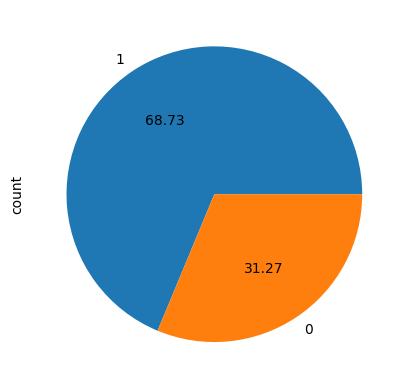

In [30]:
y.value_counts().plot.pie(autopct='%.2f')

In [31]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [32]:
ros = RandomOverSampler(sampling_strategy=1)

x_ros, y_ros = ros.fit_resample(x, y)

<Axes: ylabel='count'>

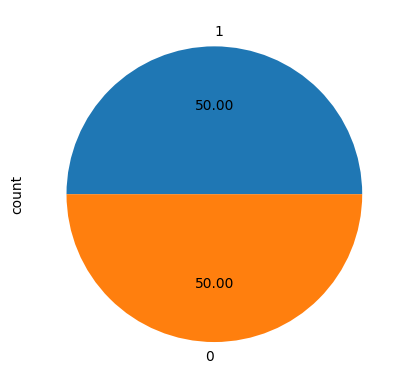

In [33]:
y_ros.value_counts().plot.pie(autopct='%.2f')

In [34]:
x_ross = x_ros.fillna(method='ffill',axis=1)

C:\Users\Erfan\AppData\Local\Temp\ipykernel_21992\441585253.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_ross = x_ros.fillna(method='ffill',axis=1)


In [35]:
x_ross.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [36]:
y_ros.isnull().sum()

0

In [37]:
x_norm = scaler.fit_transform(x_ross)
x_norm

array([[ 0.45735003, -1.29590319, -0.72308254, ...,  0.26814986,
         0.54814437,  1.21309126],
       [ 0.45735003,  0.77166258,  0.26442824, ...,  0.26814986,
         0.54814437, -1.26296442],
       [ 0.45735003,  0.77166258, -0.72308254, ...,  0.26814986,
         0.54814437,  1.21309126],
       ...,
       [ 0.45735003, -1.29590319, -0.72308254, ...,  0.26814986,
        -1.8243369 , -1.26296442],
       [ 0.45735003,  0.77166258, -0.72308254, ..., -2.47621328,
         0.54814437,  1.21309126],
       [-2.18650907, -1.29590319, -0.72308254, ...,  0.26814986,
        -1.8243369 , -0.02493658]])

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
xtrain, xtest, ytrain, ytest = train_test_split(x_norm, y_ros, test_size=0.2, random_state=2)

In [40]:
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True)

In [41]:
models, predictions = clf.fit(xtrain, xtest, ytrain, ytest)
print(models)

100%|██████████| 29/29 [00:01<00:00, 26.92it/s]

[LightGBM] [Info] Number of positive: 338, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 474
[LightGBM] [Info] Number of data points in the train set: 675, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500741 -> initscore=0.002963
[LightGBM] [Info] Start training from score 0.002963
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [43]:
n_estimators_range = list(range(1, 101))
max_depth_range = list(range(1, 11))
param_grid = dict(n_estimators=n_estimators_range, max_depth=max_depth_range)
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=10, scoring='accuracy')
grid.fit(x_ross, y_ros)
grid.cv_results_

{'mean_fit_time': array([0.00279014, 0.00348785, 0.00408528, 0.00457921, 0.00557997,
        0.00613167, 0.00684907, 0.00820389, 0.00906911, 0.01017029,
        0.01111994, 0.01262965, 0.01275799, 0.01345108, 0.01466556,
        0.01914039, 0.01842353, 0.01859405, 0.0205976 , 0.01834788,
        0.01896348, 0.0211648 , 0.02093093, 0.02194748, 0.02913992,
        0.02429006, 0.02701814, 0.02740812, 0.02748518, 0.02792134,
        0.02766411, 0.03302639, 0.03768451, 0.03185191, 0.03323934,
        0.03514519, 0.03747337, 0.03557065, 0.0348516 , 0.03510215,
        0.03653891, 0.03866189, 0.039623  , 0.04309113, 0.04072092,
        0.04163191, 0.04299698, 0.04168842, 0.04311194, 0.04321799,
        0.04468136, 0.05093808, 0.05240517, 0.0513555 , 0.04952185,
        0.0478786 , 0.05417628, 0.05425704, 0.05344028, 0.05221   ,
        0.05159285, 0.05419517, 0.05594745, 0.05617349, 0.05698404,
        0.05573518, 0.05948591, 0.05935535, 0.06319611, 0.06727002,
        0.06728506, 0.0656847 ,

In [44]:
grid.best_params_

{'max_depth': 10, 'n_estimators': 84}

In [45]:
clff = RandomForestClassifier(n_estimators=43, max_depth=10, random_state=42)
clff.fit(xtrain, ytrain)

RandomForestClassifier(max_depth=10, n_estimators=43, random_state=42)

In [46]:
ypred = clff.predict(xtest)

In [47]:
print('Accuracy:', metrics.accuracy_score(ytest, ypred))

Accuracy: 0.8461538461538461
